<a href="https://colab.research.google.com/github/mewtwox44/ML-SKILL/blob/main/week_7_Skill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload the House Prices train.csv file:


Saving train (1).csv to train (1).csv

Dataset loaded successfully!
File: train (1).csv

========== FIRST 5 ROWS ==========
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  .

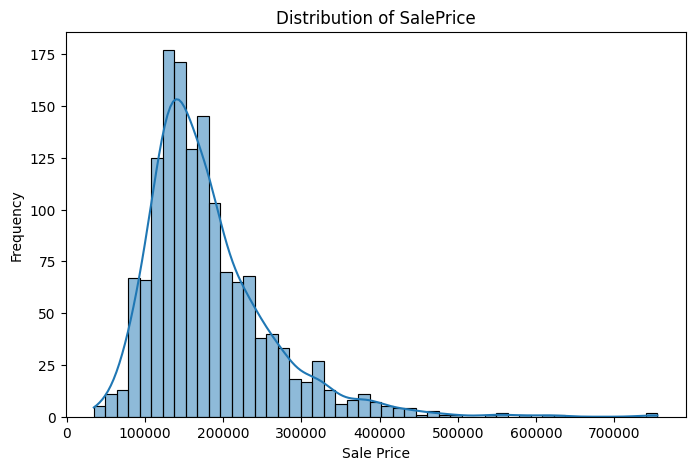


========== SELECTED FEATURES ==========
Numerical features:
['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'LotArea']

Categorical features:
['Neighborhood', 'HouseStyle', 'KitchenQual', 'CentralAir']

========== MISSING VALUES AFTER CLEANING ==========
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
LotArea         0
Neighborhood    0
HouseStyle      0
KitchenQual     0
CentralAir      0
dtype: int64

========== BEFORE ENCODING ==========
   OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0            7       1710           2          856       2003         2   
1            6       1262           2         1262       1976         2   
2            7       1786           2          920       2001         2   
3            7       1717           3          756       1915         1   
4            8       2198           3         1145       2000         2   

   LotAr

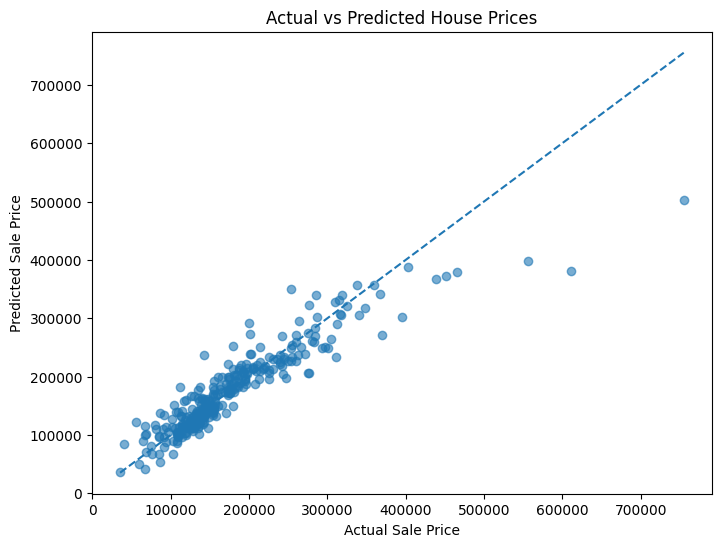

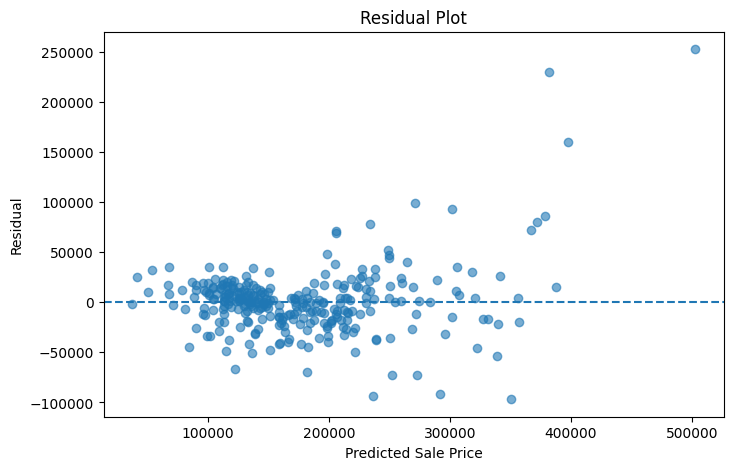


========== MODEL COEFFICIENTS ==========
                 Feature   Coefficient  Absolute_Coefficient
1              GrLivArea  28193.876166          28193.876166
40        KitchenQual_TA -26739.500919          26739.500919
39        KitchenQual_Gd -22012.025136          22012.025136
0            OverallQual  18010.970564          18010.970564
22  Neighborhood_NridgHt  12700.675069          12700.675069
21  Neighborhood_NoRidge  12485.988899          12485.988899
12  Neighborhood_Crawfor   8632.966642           8632.966642
28  Neighborhood_StoneBr   8142.005668           8142.005668
38        KitchenQual_Fa  -8119.497688           8119.497688
2             GarageCars   7958.640003           7958.640003
4              YearBuilt   7241.675087           7241.675087
27  Neighborhood_Somerst   6959.732233           6959.732233
11  Neighborhood_CollgCr   6463.389216           6463.389216
6                LotArea   6214.664810           6214.664810
32     HouseStyle_1Story   6193.648742     

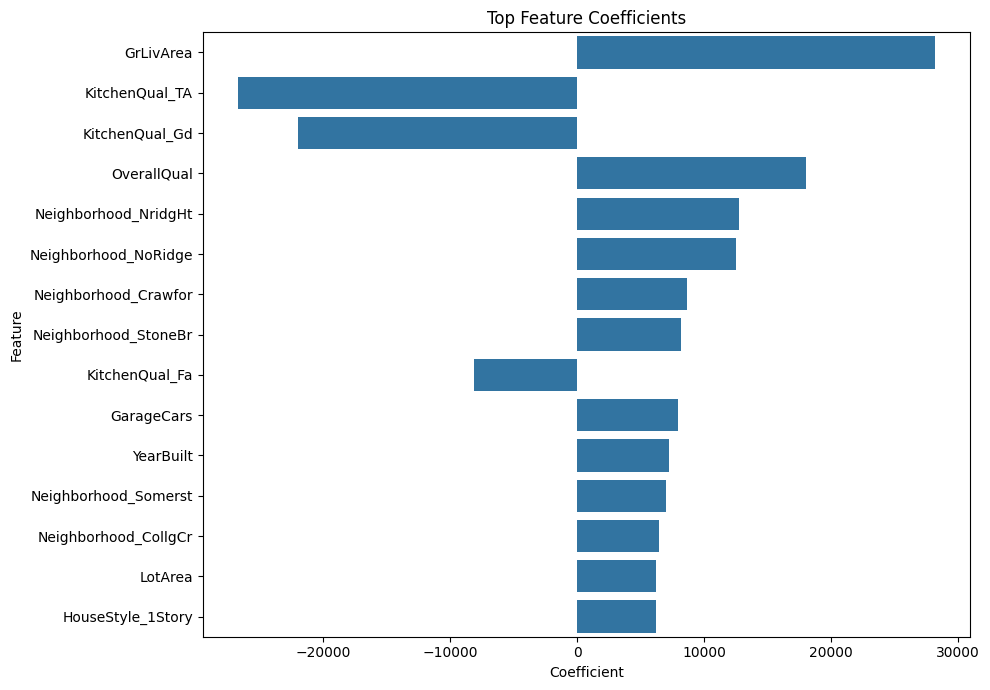

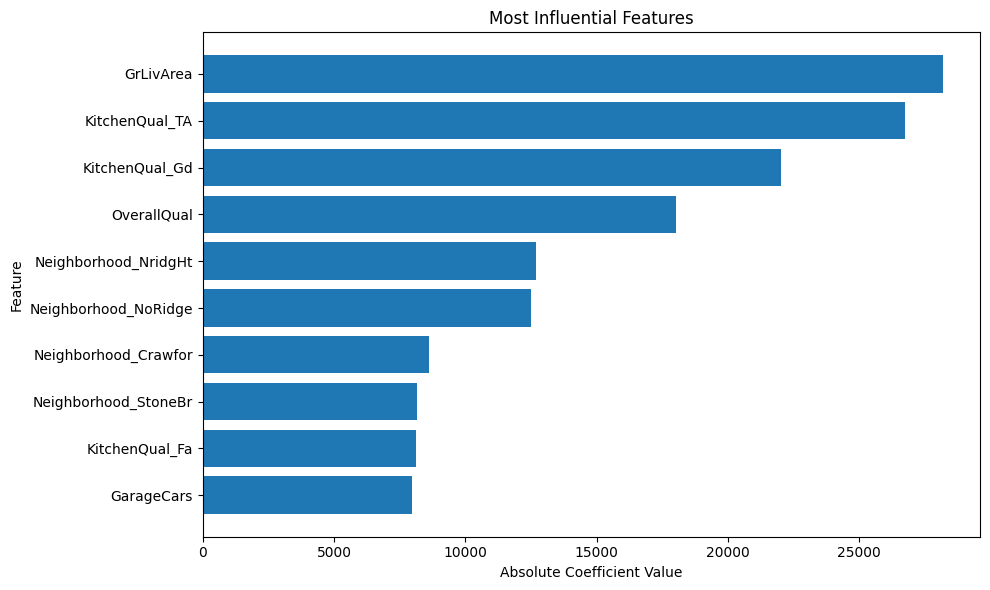

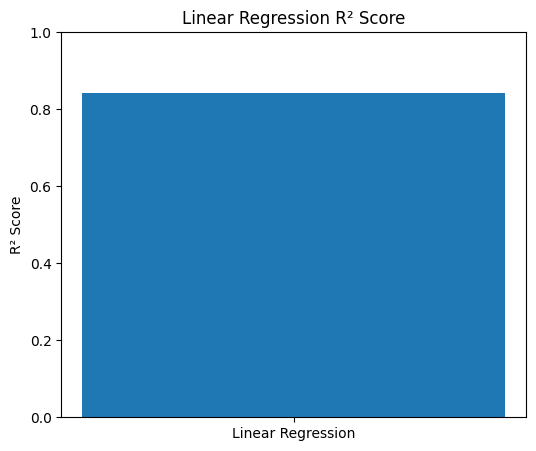


========== SAMPLE PREDICTIONS ==========
   Actual SalePrice  Predicted SalePrice
0            154500        137148.994458
1            325000        321024.306911
2            115000        116900.291246
3            159000        171021.414833
4            315500        307940.652668
5             75500         67839.137978
6            311500        233900.404827
7            146000        146274.995934
8             84500         67623.932862
9            135500        120912.540327

Linear Regression was successfully implemented to predict house prices.
Categorical variables were converted into numerical values using One-Hot Encoding.
Numerical and encoded features were standardized using StandardScaler.
The model achieved an R² score of 0.8422.
The Root Mean Squared Error (RMSE) was 34785.73.
The actual-vs-predicted plot and residual plot were used to analyze model performance.
Model coefficients were also analyzed to identify the features having the largest influence on house-p

In [1]:
# ============================================================
# PROJECT 7
# LINEAR REGRESSION, FEATURE SCALING AND ENCODING
# Dataset: House Prices - Advanced Regression Techniques
# Target: SalePrice
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("Upload the House Prices train.csv file:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("File:", filename)


# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())


# ============================================================
# 4. TARGET VARIABLE
# ============================================================

target = "SalePrice"

print("\nTarget variable:", target)


# ============================================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================================

# SalePrice distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df[target],
    kde=True
)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()


# ============================================================
# 6. IMPORTANT NUMERICAL FEATURES
# ============================================================

numerical_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "FullBath",
    "LotArea"
]


# ============================================================
# 7. IMPORTANT CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "CentralAir"
]


# Check that required columns exist

required_features = numerical_features + categorical_features + [target]

missing_columns = [
    col for col in required_features
    if col not in df.columns
]

if len(missing_columns) > 0:

    print("\nMissing required columns:")
    print(missing_columns)

    raise ValueError(
        "The uploaded dataset does not contain all required columns."
    )


# ============================================================
# 8. CREATE FEATURE DATAFRAME
# ============================================================

X = df[numerical_features + categorical_features].copy()

y = df[target].copy()


print("\n========== SELECTED FEATURES ==========")

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


# ============================================================
# 9. HANDLE MISSING VALUES
# ============================================================

# Numerical features -> median

for column in numerical_features:

    X[column] = X[column].fillna(
        X[column].median()
    )


# Categorical features -> mode

for column in categorical_features:

    X[column] = X[column].fillna(
        X[column].mode()[0]
    )


print("\n========== MISSING VALUES AFTER CLEANING ==========")

print(X.isnull().sum())


# ============================================================
# 10. ENCODE CATEGORICAL FEATURES
# ============================================================

print("\n========== BEFORE ENCODING ==========")

print(X.head())

print("\nShape before encoding:", X.shape)


# One-hot encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)


print("\n========== AFTER ENCODING ==========")

print(X_encoded.head())

print("\nShape after encoding:", X_encoded.shape)


# ============================================================
# 11. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== TRAIN-TEST SPLIT ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ============================================================
# 12. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


print("\nFeature scaling completed.")


# ============================================================
# 13. LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()


# ============================================================
# 14. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


print("\n========== MODEL TRAINING ==========")

print("Linear Regression model trained successfully.")


# ============================================================
# 15. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 16. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n========== MODEL PERFORMANCE ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))


# ============================================================
# 17. PERFORMANCE SUMMARY TABLE
# ============================================================

performance_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],

    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})


print("\n========== PERFORMANCE SUMMARY ==========")

print(performance_df)


# ============================================================
# 18. ACTUAL VS PREDICTED VALUES
# ============================================================

comparison_df = pd.DataFrame({

    "Actual SalePrice": y_test.values,

    "Predicted SalePrice": y_pred

})


print("\n========== ACTUAL VS PREDICTED ==========")

print(comparison_df.head(20))


# ============================================================
# 19. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title(
    "Actual vs Predicted House Prices"
)

# Perfect prediction reference line

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()


# ============================================================
# 20. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test - y_pred


plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")

plt.title(
    "Residual Plot"
)

plt.show()




coefficient_df = pd.DataFrame({

    "Feature": X_encoded.columns,

    "Coefficient": model.coef_

})


coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)


coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)


print("\n========== MODEL COEFFICIENTS ==========")

print(
    coefficient_df.head(20)
)




top_coefficients = coefficient_df.head(15)


plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Feature Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()


# ============================================================
# 23. FEATURE IMPORTANCE BASED ON COEFFICIENT MAGNITUDE
# ============================================================

top_features = coefficient_df.head(10)


plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel(
    "Absolute Coefficient Value"
)

plt.ylabel("Feature")

plt.title(
    "Most Influential Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()



# R² score

plt.figure(figsize=(6, 5))

plt.bar(
    ["Linear Regression"],
    [r2]
)

plt.ylim(0, 1)

plt.ylabel("R² Score")

plt.title(
    "Linear Regression R² Score"
)

plt.show()


sample_predictions = comparison_df.head(10).copy()

print("\n========== SAMPLE PREDICTIONS ==========")

print(sample_predictions)




print("\n===================================================")



print(
    "Linear Regression was successfully implemented "
    "to predict house prices."
)

print(
    "Categorical variables were converted into numerical "
    "values using One-Hot Encoding."
)

print(
    "Numerical and encoded features were standardized "
    "using StandardScaler."
)

print(
    f"The model achieved an R² score of {r2:.4f}."
)

print(
    f"The Root Mean Squared Error (RMSE) was "
    f"{rmse:.2f}."
)

print(
    "The actual-vs-predicted plot and residual plot "
    "were used to analyze model performance."
)

print(
    "Model coefficients were also analyzed to identify "
    "the features having the largest influence on "
    "house-price predictions."
)

